# Does infraction type add predictive signal?

The model currently knows an establishment had, say, 5 infractions last time, but not what those 5 infractions were about. This notebook tests whether a compact representation of infraction category adds anything beyond the counts and severity already in the 15-feature model. Same fixed CatBoost configuration as Prompt 14/15, no tuning, one clean ablation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

## Inspecting the category fields

`typeDesc` is the more granular field, `deficiencyDesc` is the higher-level category the audit already flagged as more compact (36 raw values vs 359 for `typeDesc`).

In [2]:
raw = pd.read_csv("../Dinesafe.csv", dtype=str, low_memory=False)

norm_type = raw["typeDesc"].str.strip().str.upper().str.replace(r"\s+", " ", regex=True)
print("typeDesc: raw unique =", raw["typeDesc"].nunique(), " case-normalized unique =", norm_type.nunique())
print("deficiencyDesc unique =", raw["deficiencyDesc"].nunique())

typeDesc: raw unique = 359  case-normalized unique = 262
deficiencyDesc unique = 36


In [3]:
type_vc = norm_type.value_counts()
type_total = norm_type.notna().sum()
print("typeDesc top-20 coverage:", round(type_vc.head(20).sum() / type_total, 3))

def_vc = raw["deficiencyDesc"].value_counts()
def_total = raw["deficiencyDesc"].notna().sum()
print("deficiencyDesc top-10 coverage:", round(def_vc.head(10).sum() / def_total, 3))
print("deficiencyDesc top-15 coverage:", round(def_vc.head(15).sum() / def_total, 3))

typeDesc top-20 coverage: 0.737
deficiencyDesc top-10 coverage: 0.839
deficiencyDesc top-15 coverage: 0.925


Even after normalizing case, `typeDesc` still has 262 distinct values with a long thin tail (top 20 only cover 74%). `deficiencyDesc` is far more compact: the top 10 of its 36 values alone cover 84%, top 15 covers 93%. Per the research design (use `typeDesc` unless it's too sparse/inconsistent), `deficiencyDesc` is the better category field here and is used as the primary category field for this experiment.

Looking at the raw `deficiencyDesc` values, there appear to be two overlapping coding schemes in the data (a legacy numeric-prefix style like `"05. MAINTENANCE / SANITATION..."` and a newer letter-number style like `"5C. Proper maintenance..."`), consistent with the mixed-pipeline formatting issues already documented in `DATA_RECONSTRUCTION.md`. No manual mapping between the two schemes is attempted here, they're kept as separate categories, since guessing at an equivalence would not be something verified in the data.

## Choosing retained categories

Rule, fixed before any test evaluation: retain categories representing at least 1% of infraction rows, then apply the 15-feature safeguard cap (each category produces 2 features, 365-day and 730-day, so at most 7 categories keeps the count at or under 15).

In [4]:
dedup_cols = ["estId", "inspectionDate", "typeDesc", "deficiencyDesc", "severity", "OutcomeDate", "OutcomeDesc", "amountFined"]
raw_clean = raw.drop_duplicates(subset=dedup_cols, keep="first").copy()
print("raw rows:", len(raw), "-> after removing confirmed duplicate infractions (see LONGITUDINAL_DATASET.md):", len(raw_clean))

vc = raw_clean["deficiencyDesc"].value_counts()
total_infractions = raw_clean["deficiencyDesc"].notna().sum()
one_pct = total_infractions * 0.01
n_above_threshold = (vc >= one_pct).sum()
print("categories at or above 1% of infraction rows:", n_above_threshold)
print("that would need", n_above_threshold * 2, "features, exceeding the 15-feature cap, so retaining only the top 7")

raw rows: 115899 -> after removing confirmed duplicate infractions (see LONGITUDINAL_DATASET.md): 115539
categories at or above 1% of infraction rows: 16
that would need 32 features, exceeding the 15-feature cap, so retaining only the top 7


In [5]:
RETAINED = vc.head(7).index.tolist()
SLUGS = ["maintenance_of_rooms", "non_food_surface_sanitation", "handwashing_sink",
         "admin_requirements_a", "utensil_equipment_procedures", "administrative_requirements",
         "employee_hygiene_handwashing"]
CAT_MAP = dict(zip(RETAINED, SLUGS))

for cat, slug in CAT_MAP.items():
    print(f"{slug}: {cat} ({vc[cat]} rows, {round(vc[cat]/total_infractions, 4)*100:.2f}% of infractions)")

print("\ntotal coverage of the 7 retained categories:", round(vc.head(7).sum() / total_infractions, 4))

maintenance_of_rooms: 5C. Proper maintenance / washing of rooms (including washrooms) (28804 rows, 39.37% of infractions)
non_food_surface_sanitation: 05. MAINTENANCE / SANITATION OF NON-FOOD CONTACT SURFACES / EQUIPMENT (12998 rows, 17.77% of infractions)
handwashing_sink: 3A. Separate and convenient hand washing sink(s) (4178 rows, 5.71% of infractions)
admin_requirements_a: A. OPERATOR FAIL TO MEET ADMINISTRATIVE REQUIREMENTS OF (2760 rows, 3.77% of infractions)
utensil_equipment_procedures: 2C. Proper utensils/equipment and/or procedures used to ensure (2568 rows, 3.51% of infractions)
administrative_requirements: ADMINISTRATIVE REQUIREMENTS (2411 rows, 3.30% of infractions)
employee_hygiene_handwashing: 03. EMPLOYEE HYGIENE AND HANDWASHING (2188 rows, 2.99% of infractions)

total coverage of the 7 retained categories: 0.7642


7 categories, 76.4% of infraction rows covered. No `Other` bucket is added, keeping the representation compact as instructed, at the cost of not representing the remaining 23.6% of infractions (a mix of many smaller categories).

## Building the category-history features

Category information only exists in the current DineSafe CSV (`deficiencyDesc`), not in the historical files, which only have a free-text `Infraction Details` field under a different schema. Historical-sourced inspections in the longitudinal table therefore get a category count of exactly zero, not a missing value, this matches the existing project rule that a feature should be zero when there's genuinely no information to count, not left undefined. The existing 15 features already correctly count historical infractions by total/severity, only the category breakdown is unavailable for the historical portion.

In [6]:
raw_clean["slug"] = raw_clean["deficiencyDesc"].map(CAT_MAP)

cat_counts = (
    raw_clean.dropna(subset=["slug"])
    .groupby(["estId", "inspectionDate", "slug"]).size()
    .unstack(fill_value=0)
)
for s in SLUGS:
    if s not in cat_counts.columns:
        cat_counts[s] = 0
cat_counts = cat_counts[SLUGS].reset_index()
cat_counts["inspectionDate"] = pd.to_datetime(cat_counts["inspectionDate"])

long = pd.read_csv("../outputs/inspection_level_longitudinal.csv", parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)

long = long.merge(cat_counts, on=["estId", "inspectionDate"], how="left")
for s in SLUGS:
    long[s] = long[s].fillna(0).astype(int)

print("longitudinal rows:", len(long))
print("rows with at least one retained-category infraction:", (long[SLUGS].sum(axis=1) > 0).sum())

longitudinal rows: 262547
rows with at least one retained-category infraction: 32161


In [7]:
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_window(g, days, prefix, cols):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    out = {"orig_index": g["index"]}
    for c in cols:
        vals = g[c].to_numpy()
        cs = np.concatenate([[0], np.cumsum(vals)])
        lower_edge = dates - np.timedelta64(days, "D")
        low_idx = np.searchsorted(dates, lower_edge, side="left")
        idx_arr = np.arange(len(g))
        out[f"{prefix}_{c}"] = cs[idx_arr] - cs[low_idx]
    return pd.DataFrame(out)

def rolling_count(g, days, prefix):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    lower_edge = dates - np.timedelta64(days, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")
    idx_arr = np.arange(len(g))
    return pd.DataFrame({"orig_index": g["index"], f"{prefix}_n_inspections": idx_arr - low_idx})

long["_infr_"] = long["n_infractions"]
long["_crucial_"] = long["n_crucial"]
long["_nonpass_"] = long["is_non_pass"]
base_cols = ["_infr_", "_crucial_", "_nonpass_"]

rolled_365 = long.groupby("estId", group_keys=False).apply(rolling_window, days=365, prefix="prior_365d", cols=base_cols + SLUGS).set_index("orig_index")
rolled_730 = long.groupby("estId", group_keys=False).apply(rolling_window, days=730, prefix="prior_730d", cols=base_cols + SLUGS).set_index("orig_index")
n_365 = long.groupby("estId", group_keys=False).apply(rolling_count, days=365, prefix="prior_365d").set_index("orig_index")
n_730 = long.groupby("estId", group_keys=False).apply(rolling_count, days=730, prefix="prior_730d").set_index("orig_index")

long_feat = long.join(rolled_365).join(rolled_730).join(n_365).join(n_730)
long_feat = long_feat.rename(columns={
    "prior_365d__infr_": "prior_365d_total_infractions", "prior_365d__crucial_": "prior_365d_crucial_infractions",
    "prior_365d__nonpass_": "prior_365d_n_non_pass", "prior_730d__infr_": "prior_730d_total_infractions",
    "prior_730d__crucial_": "prior_730d_crucial_infractions", "prior_730d__nonpass_": "prior_730d_n_non_pass",
})

cat_feature_cols = []
for s in SLUGS:
    cat_feature_cols.append(f"prior_365d_{s}")
    cat_feature_cols.append(f"prior_730d_{s}")

print("category feature columns:", len(cat_feature_cols))
assert len(cat_feature_cols) <= 15
cat_feature_cols

category feature columns: 14


['prior_365d_maintenance_of_rooms',
 'prior_730d_maintenance_of_rooms',
 'prior_365d_non_food_surface_sanitation',
 'prior_730d_non_food_surface_sanitation',
 'prior_365d_handwashing_sink',
 'prior_730d_handwashing_sink',
 'prior_365d_admin_requirements_a',
 'prior_730d_admin_requirements_a',
 'prior_365d_utensil_equipment_procedures',
 'prior_730d_utensil_equipment_procedures',
 'prior_365d_administrative_requirements',
 'prior_730d_administrative_requirements',
 'prior_365d_employee_hygiene_handwashing',
 'prior_730d_employee_hygiene_handwashing']

## Merge onto the existing prediction-event dataset

Same rows as the existing prediction-event file, nothing dropped for missing category history (there isn't any, it's zero-filled by construction).

In [8]:
pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)

merge_cols = ["estId", "inspectionDate", "prior_730d_total_infractions", "prior_730d_n_non_pass",
              "prior_730d_crucial_infractions", "prior_730d_n_inspections"] + cat_feature_cols
df = pred.merge(long_feat[merge_cols], on=["estId", "inspectionDate"], how="left")

assert len(df) == len(pred)
for c in cat_feature_cols:
    assert df[c].isna().sum() == 0
    assert (df[c] >= 0).all()
print("merged rows:", len(df), "- no missing category features, no negative counts")

merged rows: 69766 - no missing category features, no negative counts


## Feature validation

Brute-force recomputation of both windows' category counts on 300 random rows, directly filtering the deduplicated raw infraction rows.

In [9]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(df.index, size=300, replace=False)
mismatches = 0

for i in sample_idx:
    row = df.loc[i]
    est = row["estId"]; t = row["inspectionDate"]
    hist_infr = raw_clean[raw_clean["estId"] == est].copy()
    hist_infr["inspectionDate"] = pd.to_datetime(hist_infr["inspectionDate"])
    hist_infr = hist_infr[hist_infr["inspectionDate"] < t]

    for days, prefix in [(365, "prior_365d"), (730, "prior_730d")]:
        window = hist_infr[hist_infr["inspectionDate"] >= t - pd.Timedelta(days=days)]
        for cat_str, slug in CAT_MAP.items():
            expected = (window["deficiencyDesc"] == cat_str).sum()
            got = row[f"{prefix}_{slug}"]
            if expected != got:
                mismatches += 1

print("brute-force mismatches on 300 sampled rows x 7 categories x 2 windows (must be 0):", mismatches)
assert mismatches == 0

brute-force mismatches on 300 sampled rows x 7 categories x 2 windows (must be 0): 0


## Baseline and category-augmented feature sets

In [10]:
BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]

FEATURES_15 = BASE + HIST365 + HIST730
FEATURES_29 = FEATURES_15 + cat_feature_cols
assert len(FEATURES_15) == 15
assert len(FEATURES_29) == 29

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
outcome_cols = {"OutcomeDate", "OutcomeDesc", "amountFined", "inspectionStatus"}
assert identifier_cols.isdisjoint(FEATURES_29)
assert outcome_cols.isdisjoint(FEATURES_29)

## Strict temporal split, unchanged

In [11]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
val = df[(df["inspectionDate"] >= train_cut) & (df["inspectionDate"] < val_cut)].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

assert len(train) == 45334 and len(val) == 11740 and len(test) == 12692
assert train["inspectionDate"].max() < val["inspectionDate"].min()
assert val["inspectionDate"].max() < test["inspectionDate"].min()
print("split unchanged: train 45,334 / val 11,740 / test 12,692")

split unchanged: train 45,334 / val 11,740 / test 12,692


## Train both models, identical rows, identical CatBoost config

In [12]:
def run_model(features, label):
    X_train, y_train = train[features], train["target"]
    X_val, y_val = val[features], val["target"]
    X_test, y_test = test[features], test["target"]

    model = CatBoostClassifier(
        iterations=300, depth=4, learning_rate=0.05, loss_function="Logloss",
        auto_class_weights="Balanced", random_seed=42, verbose=False,
    )
    model.fit(X_train, y_train)

    val_proba = model.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_proba)
    val_roc_auc = roc_auc_score(y_val, val_proba)

    thresh_rows = []
    for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
        p = (val_proba >= t).astype(int)
        thresh_rows.append({"threshold": t, "f1": f1_score(y_val, p, zero_division=0)})
    thresh_df = pd.DataFrame(thresh_rows)
    best_t = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]

    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= best_t).astype(int)

    metrics = {
        "label": label,
        "val_pr_auc": val_pr_auc, "val_roc_auc": val_roc_auc, "threshold": best_t,
        "test_pr_auc": average_precision_score(y_test, test_proba),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test, test_pred),
    }
    cm = confusion_matrix(y_test, test_pred)
    return model, metrics, cm, test_proba

In [13]:
model15, metrics15, cm15, proba15 = run_model(FEATURES_15, "catboost_15_baseline")
print(metrics15)
print(cm15)

{'label': 'catboost_15_baseline', 'val_pr_auc': 0.17119999099665015, 'val_roc_auc': 0.7335191135474568, 'threshold': np.float64(0.7), 'test_pr_auc': 0.17421968990108275, 'test_roc_auc': 0.7337115866223876, 'test_precision': 0.20975965040058267, 'test_recall': 0.3018867924528302, 'test_f1': 0.2475290073055436, 'test_accuracy': 0.8620390797352663}
[[10653  1085]
 [  666   288]]


In [14]:
model29, metrics29, cm29, proba29 = run_model(FEATURES_29, "catboost_29_with_categories")
print(metrics29)
print(cm29)

{'label': 'catboost_29_with_categories', 'val_pr_auc': 0.17234536091520564, 'val_roc_auc': 0.7301648927668251, 'threshold': np.float64(0.7), 'test_pr_auc': 0.17282941154578624, 'test_roc_auc': 0.7327411499785855, 'test_precision': 0.21194029850746268, 'test_recall': 0.2976939203354298, 'test_f1': 0.24760244115082825, 'test_accuracy': 0.8640088244563504}
[[10682  1056]
 [  670   284]]


## Comparison

In [15]:
compare = pd.DataFrame([metrics15, metrics29])
compare = compare[["label", "val_pr_auc", "val_roc_auc", "threshold", "test_pr_auc",
                    "test_roc_auc", "test_precision", "test_recall", "test_f1", "test_accuracy"]]
compare

,label,val_pr_auc,val_roc_auc,threshold,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,test_accuracy
0,catboost_15_baseline,0.171200,0.733519,0.7,0.174220,0.733712,0.20976,0.301887,0.247529,0.862039
1,catboost_29_with_categories,0.172345,0.730165,0.7,0.172829,0.732741,0.21194,0.297694,0.247602,0.864009


In [16]:
saved = pd.read_csv("../outputs/tuned_model_results.csv").iloc[0]
print("saved Prompt 14/15 tuned CatBoost test PR-AUC:", saved["test_pr_auc"], " this notebook's 15-feature reproduction:", metrics15["test_pr_auc"])
assert abs(saved["test_pr_auc"] - metrics15["test_pr_auc"]) < 1e-9
print("15-feature baseline reproduces the earlier tuned result exactly")

saved Prompt 14/15 tuned CatBoost test PR-AUC: 0.1742196899010827  this notebook's 15-feature reproduction: 0.17421968990108275
15-feature baseline reproduces the earlier tuned result exactly


Adding the 7 category history features barely moves anything, and if anything moves it slightly the wrong way: test PR-AUC 0.1742 to 0.1728, ROC-AUC 0.7337 to 0.7327. F1 is essentially unchanged (0.2475 to 0.2476). This is a tiny, non-meaningful change, closer to noise than to a real improvement, and it doesn't clear the bar of even the "moderate improvement" outcome described in the research design.

## PR and ROC curves

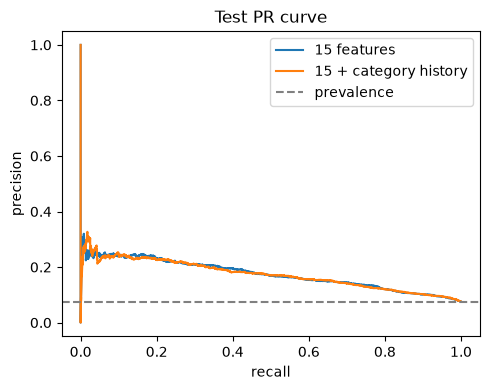

In [17]:
prec15, rec15, _ = precision_recall_curve(test["target"], proba15)
prec29, rec29, _ = precision_recall_curve(test["target"], proba29)

plt.figure(figsize=(5, 4))
plt.plot(rec15, prec15, label="15 features")
plt.plot(rec29, prec29, label="15 + category history")
plt.axhline(test["target"].mean(), linestyle="--", color="gray", label="prevalence")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Test PR curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_category_pr_curve.png", dpi=100)
plt.show()

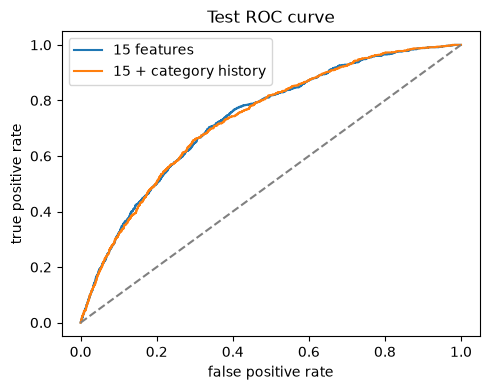

In [18]:
fpr15, tpr15, _ = roc_curve(test["target"], proba15)
fpr29, tpr29, _ = roc_curve(test["target"], proba29)

plt.figure(figsize=(5, 4))
plt.plot(fpr15, tpr15, label="15 features")
plt.plot(fpr29, tpr29, label="15 + category history")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Test ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_category_roc_curve.png", dpi=100)
plt.show()

## Feature importance (29-feature model)

In [19]:
importances = model29.get_feature_importance()
imp_df = pd.DataFrame({"feature": FEATURES_29, "importance": importances}).sort_values("importance", ascending=False).reset_index(drop=True)
imp_df

,feature,importance
0,prior_730d_total_infractions,18.961273
1,days_since_previous_inspection,16.345426
2,prev_non_pass,13.036351
3,prior_365d_total_infractions,9.415749
4,n_inspections_seen_so_far,7.528148
5,prev_total_infractions,3.673399
6,prior_730d_n_inspections,3.479806
7,prior_365d_n_inspections,3.401065
8,prior_730d_crucial_infractions,3.310314
9,prev_minor,3.096403


The category features occupy the lower half of the importance ranking, and three of the seven categories (`non_food_surface_sanitation`, `administrative_requirements`, `employee_hygiene_handwashing`) get exactly zero importance, the model never splits on them at all. The four categories that do get some use (`maintenance_of_rooms`, `handwashing_sink`, `admin_requirements_a`, `utensil_equipment_procedures`) still rank well below the original count/severity features. This is consistent with the near-zero change in the headline metrics.

## Save results

In [20]:
results = pd.DataFrame([
    {"model": "catboost", "feature_set": "15 existing longitudinal features", "n_category_features": 0,
     "val_pr_auc": metrics15["val_pr_auc"], "val_roc_auc": metrics15["val_roc_auc"], "threshold": metrics15["threshold"],
     "test_pr_auc": metrics15["test_pr_auc"], "test_roc_auc": metrics15["test_roc_auc"],
     "test_precision": metrics15["test_precision"], "test_recall": metrics15["test_recall"],
     "test_f1": metrics15["test_f1"], "test_accuracy": metrics15["test_accuracy"],
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
    {"model": "catboost", "feature_set": "15 existing + 7 infraction-category history features (14 new)", "n_category_features": 14,
     "val_pr_auc": metrics29["val_pr_auc"], "val_roc_auc": metrics29["val_roc_auc"], "threshold": metrics29["threshold"],
     "test_pr_auc": metrics29["test_pr_auc"], "test_roc_auc": metrics29["test_roc_auc"],
     "test_precision": metrics29["test_precision"], "test_recall": metrics29["test_recall"],
     "test_f1": metrics29["test_f1"], "test_accuracy": metrics29["test_accuracy"],
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
])
results.to_csv("../outputs/catboost_category_results.csv", index=False)

category_summary = pd.DataFrame([
    {"category": cat, "coverage_fraction": round(vc[cat] / total_infractions, 4),
     "feature_365d": f"prior_365d_{slug}", "feature_730d": f"prior_730d_{slug}"}
    for cat, slug in CAT_MAP.items()
])
category_summary.to_csv("../outputs/category_feature_summary.csv", index=False)

imp_df.to_csv("../outputs/category_feature_importance.csv", index=False)

print("saved outputs/catboost_category_results.csv")
print("saved outputs/category_feature_summary.csv")
print("saved outputs/category_feature_importance.csv")

saved outputs/catboost_category_results.csv
saved outputs/category_feature_summary.csv
saved outputs/category_feature_importance.csv


## Interpretation

Knowing what kind of infraction occurred, at least in this compact 7-category form derived from `deficiencyDesc`, adds essentially nothing beyond knowing how many infractions occurred and how severe they were. Test PR-AUC moved from 0.174 to 0.173, ROC-AUC from 0.734 to 0.733, both within noise. This lines up with the stopping rule set out in the research design: inspection counts and severity, recency and history depth, engineered rate/recency features, model family, hyperparameter tuning, and now infraction-category information have all failed to produce a substantial improvement over roughly the same PR-AUC/ROC-AUC range. That's a fairly strong, cumulative signal that the current DineSafe inspection-history representation has limited predictive power for this task, not evidence of a specific bug or a missed feature.